In [206]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error, r2_score
import joblib

In [207]:
data = pd.read_csv("../data/cars_dataset.csv")
df = data.copy()

In [208]:
df.head()

,ID,Mark,Model,Year,Price_USD,Mileage,Engine,Fuel,Gearbox
0,2059468,Opel,Omega,1990,1900,300,0,"Бензин, 1.8 л.",Ручна / Механіка
1,39346065,Mercedes-Benz,eVito,2021,27800,257,0,Електро,Автомат
2,38511410,Volkswagen,E-Tharu,2020,18000,31,0,Електро,Автомат
3,2057310,Skoda,Octavia,2007,14500,67,0,"Бензин, 1.6 л.",Ручна / Механіка
4,39587514,BMW,5 Series,2017,36200,129,0,"Дизель, 2.99 л.",Автомат


In [209]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18893 entries, 0 to 18892
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         18893 non-null  int64 
 1   Mark       18805 non-null  object
 2   Model      18039 non-null  object
 3   Year       18893 non-null  int64 
 4   Price_USD  18893 non-null  int64 
 5   Mileage    18893 non-null  int64 
 6   Engine     18893 non-null  int64 
 7   Fuel       18893 non-null  object
 8   Gearbox    18893 non-null  object
dtypes: int64(5), object(4)
memory usage: 1.3+ MB


In [210]:
df.describe()

,ID,Year,Price_USD,Mileage,Engine
count,1.889300e+04,18893.000000,18893.000000,18893.000000,18893.0
mean,3.027777e+07,2011.019796,17951.785635,156.751019,0.0
std,1.601208e+07,9.083425,22083.457517,253.204387,0.0
min,1.891806e+06,1939.000000,0.000000,0.000000,0.0
25%,3.587842e+07,2006.000000,6700.000000,75.000000,0.0
50%,3.948316e+07,2012.000000,12500.000000,150.000000,0.0
75%,3.962777e+07,2018.000000,21455.000000,221.000000,0.0
max,3.965773e+07,2026.000000,399999.000000,32000.000000,0.0


In [211]:
# Видаляємо стовпчик 'ID', бо він не несе ніякої користі.
df = df.drop('ID',axis=1)

In [212]:
engine = df[df['Engine'] == 0]
len(engine)

18893

In [213]:
# Також видаляємо стовпчик 'Engine', бо він не несе ніякої користі.
df = df.drop('Engine',axis=1)

In [214]:
df.head(3)

,Mark,Model,Year,Price_USD,Mileage,Fuel,Gearbox
0,Opel,Omega,1990,1900,300,"Бензин, 1.8 л.",Ручна / Механіка
1,Mercedes-Benz,eVito,2021,27800,257,Електро,Автомат
2,Volkswagen,E-Tharu,2020,18000,31,Електро,Автомат


_______________________________
# Зробимо оглядовий аналіз по графікам



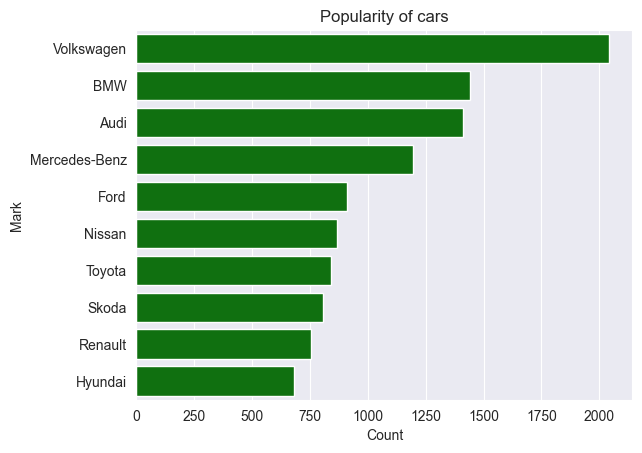

In [215]:
popularity_mark = df['Mark'].value_counts().sort_values(ascending=False)
top_10 = popularity_mark[:10]
sns.barplot(x=top_10.values, y=top_10.index, color='g')
plt.title('Popularity of cars')
plt.xlabel('Count')
plt.ylabel('Mark')
plt.show()

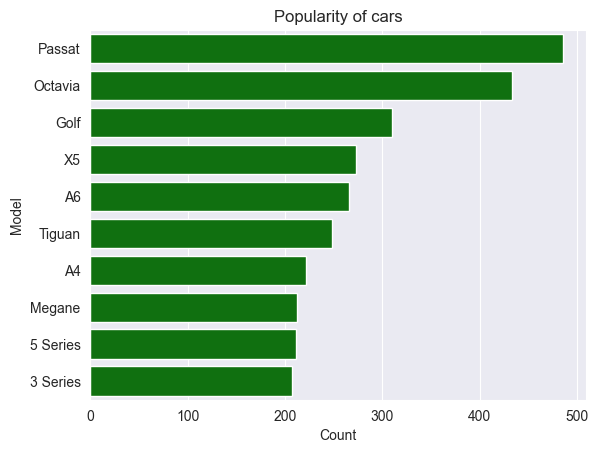

In [216]:
popularity_model = df['Model'].value_counts().sort_values(ascending=False)
top_10 = popularity_model[:10]
sns.barplot(x=top_10.values, y=top_10.index, color='g')
plt.title('Popularity of cars')
plt.xlabel('Count')
plt.ylabel('Model')
plt.show()

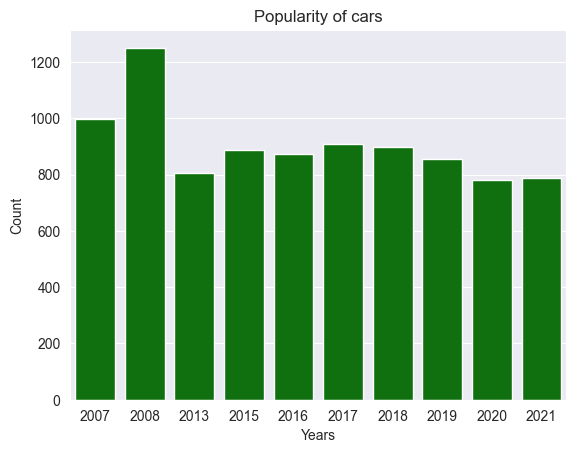

In [217]:
year = df['Year'].value_counts().sort_values(ascending=False)
sns.barplot(year[:10], color='g')
plt.title('Popularity of cars')
plt.xlabel('Years')
plt.ylabel('Count')
plt.show()

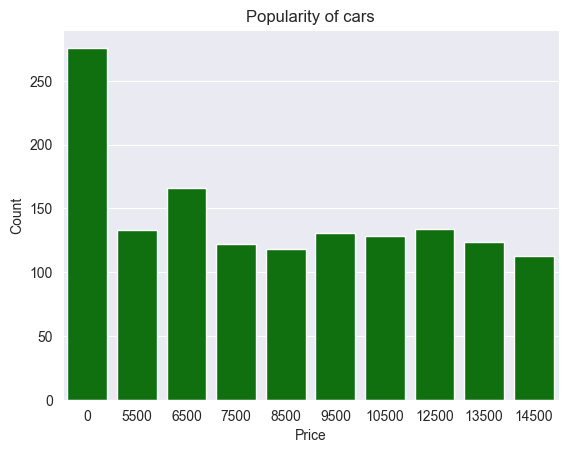

In [218]:
popular_price = df['Price_USD'].value_counts().sort_values(ascending=False)
sns.barplot(popular_price[:10], color='g')
plt.title('Popularity of cars')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

# Знайшли пусті дані, в нас не можуть коштувати авто 0. Тому нам прийдеться видалити всі авто, які не мають ціну.

In [219]:
df['Price_USD'].isna().sum()

np.int64(0)

In [220]:
df = df[df['Price_USD'] != 0]
df.shape

(18617, 7)

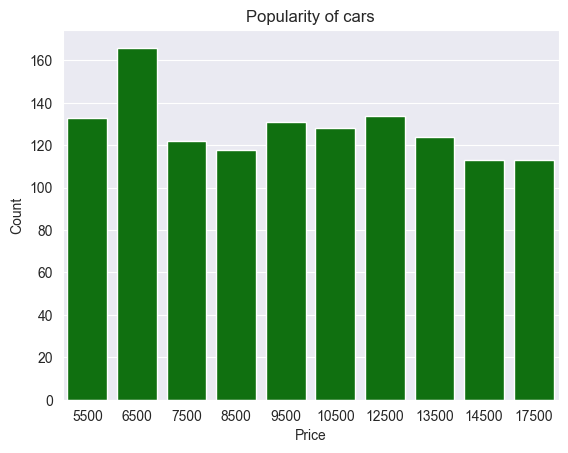

In [221]:
popular_price = df['Price_USD'].value_counts().sort_values(ascending=False)
sns.barplot(popular_price[:10], color='g')
plt.title('Popularity of cars')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

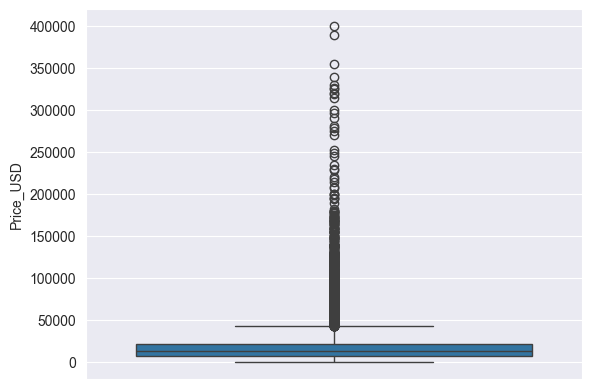

In [222]:
sns.boxplot(df['Price_USD'])
plt.show()

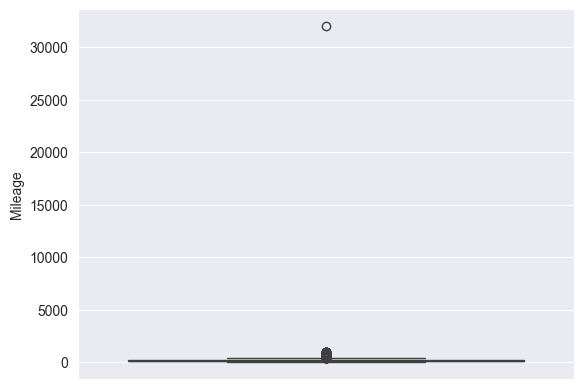

In [223]:
sns.boxplot(df['Mileage'])
plt.show()

In [224]:
df[df['Mileage'] > 1000]

,Mark,Model,Year,Price_USD,Mileage,Fuel,Gearbox
5284,Volkswagen,Passat,2008,6500,32000,"Дизель, 2 л.",Ручна / Механіка


In [225]:
df.drop(index=5284, inplace=True)

<Axes: ylabel='Year'>

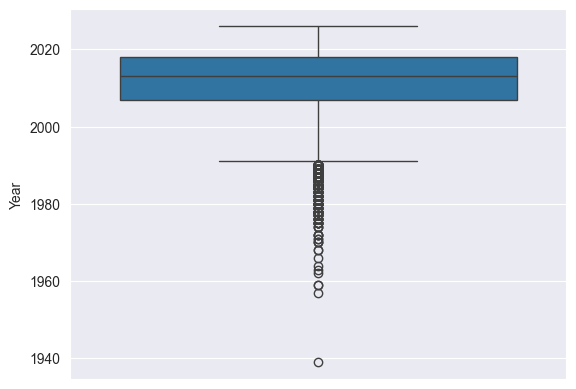

In [226]:
sns.boxplot(df['Year'])

In [227]:
df[df['Year'] < 1980]

,Mark,Model,Year,Price_USD,Mileage,Fuel,Gearbox
946,ЗИЛ,130,1977,2000,65,"Бензин, 6 л.",Ручна / Механіка
967,ГАЗ,21 Волга,1963,150,100,Не вказано,Не вказано
1204,ВАЗ,NaN,1975,400,7,Бензин,Ручна / Механіка
1452,ВАЗ / Lada,2101,1978,1300,70,"Бензин, 1.2 л.",Ручна / Механіка
1463,ВАЗ / Lada,2102,1978,204,160,"Бензин, 1.5 л.",Ручна / Механіка
...,...,...,...,...,...,...,...
16542,ГАЗ,69,1964,2222,5,"Бензин, 2 л.",Ручна / Механіка
18267,ВАЗ,2106,1976,1000,160,"Бензин, 1.6 л.",Ручна / Механіка
18544,ВАЗ,2101,1975,90,150,Бензин,Ручна / Механіка
18622,ВАЗ,2103,1975,1800,115,"Бензин, 1.4 л.",Ручна / Механіка


In [228]:
# Видаляємо дуже старі авто
df.drop(df[df['Year'] < 1980].index, inplace=True)

<Axes: ylabel='Year'>

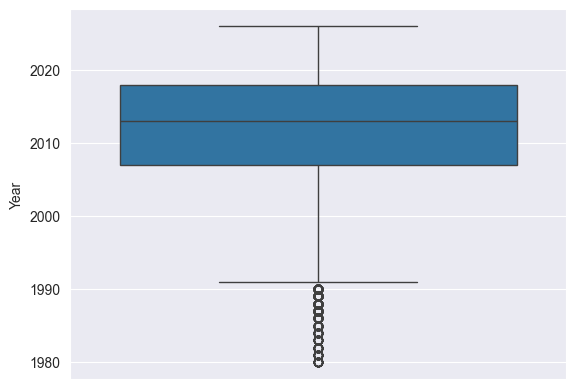

In [229]:
sns.boxplot(df['Year'])

In [230]:
# Перевіряємо, чи дійсно авто, які коштують більше n записані в $, а не в гривнях
car_more_than = df[df['Price_USD'] > 300000]
car_more_than

,Mark,Model,Year,Price_USD,Mileage,Fuel,Gearbox
3160,Mercedes-Benz,G-Class,2024,314999,11,"Гібрид (HEV), 3.98 л.",Автомат
9207,Aston Martin,DBX 707,2025,399999,1,"Бензин, 3.98 л.",Автомат
9740,Mercedes-Benz,G-Class,2025,319000,9,"Гібрид (HEV), 3.98 л.",Автомат
11266,Aston Martin,DBX 707,2024,355555,1,"Бензин, 4 л.",Автомат
11414,Rolls-Royce,Cullinan,2019,329999,63,"Бензин, 6.75 л.",Автомат
11727,Mercedes-Benz,G-Class,2025,325500,10,"Бензин, 3.98 л.",Автомат
12258,Mercedes-Benz,G-Class,2023,340000,17,"Бензин, 3.98 л.",Автомат
14414,Rolls-Royce,Ghost,2020,390000,20,"Бензин, 6.75 л.",Автомат
17641,Lamborghini,Huracan EVO,2020,320900,9,"Бензин, 5.2 л.",Автомат
18432,Mercedes-Benz,G-Class,2025,325900,1,"Бензин, 4 л.",Автомат


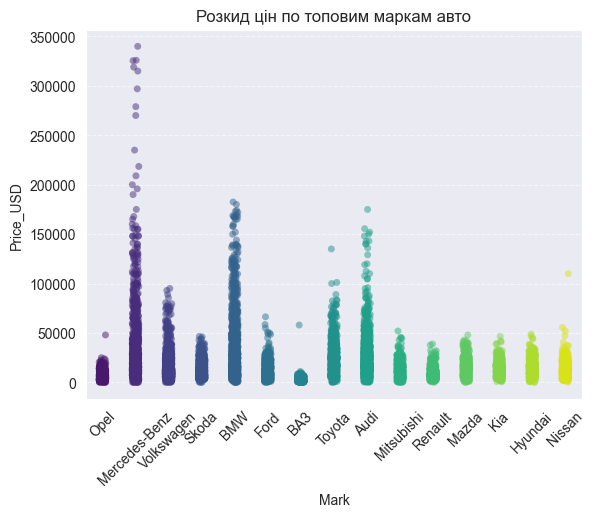

In [231]:
top_marks = df['Mark'].value_counts().nlargest(15).index
df_filtered = df[df['Mark'].isin(top_marks)]

sns.stripplot(
    data=df_filtered,
    x='Mark',
    y='Price_USD',
    hue='Mark',
    jitter=True,
    alpha=0.5,
    palette='viridis',
    legend=False
)


plt.title('Розкид цін по топовим маркам авто')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

_______________________
# Створення нових фіч


In [232]:
df.head(3)

,Mark,Model,Year,Price_USD,Mileage,Fuel,Gearbox
0,Opel,Omega,1990,1900,300,"Бензин, 1.8 л.",Ручна / Механіка
1,Mercedes-Benz,eVito,2021,27800,257,Електро,Автомат
2,Volkswagen,E-Tharu,2020,18000,31,Електро,Автомат


In [233]:
# Порахували скільки років кожній моделі

df['Age'] = 2026 - df['Year']
df.head(3)

,Mark,Model,Year,Price_USD,Mileage,Fuel,Gearbox,Age
0,Opel,Omega,1990,1900,300,"Бензин, 1.8 л.",Ручна / Механіка,36
1,Mercedes-Benz,eVito,2021,27800,257,Електро,Автомат,5
2,Volkswagen,E-Tharu,2020,18000,31,Електро,Автомат,6


In [234]:
# Розділили 'Fuel' на об'єм двигуна та тип двигуна

split_data = df['Fuel'].str.split(', ', expand=True)
df['Fuel_Type'] = split_data[0]

cleaned_capacity = split_data[1].str.replace(' л.', '')
df['Engine_Capacity'] = pd.to_numeric(cleaned_capacity, errors='coerce').fillna(0)

df.drop('Fuel', axis=1, inplace=True)

<Axes: ylabel='Engine_Capacity'>

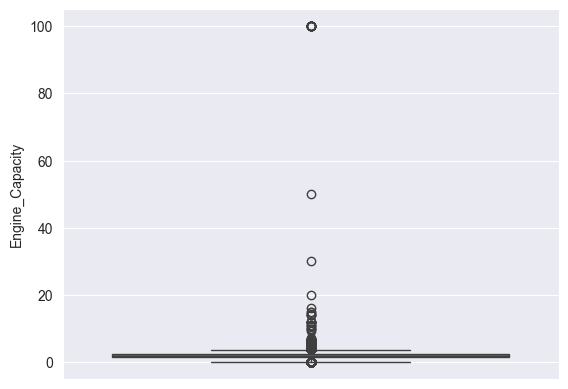

In [235]:
sns.boxplot(df['Engine_Capacity'])

In [236]:
df[df['Engine_Capacity'] > 40]

,Mark,Model,Year,Price_USD,Mileage,Gearbox,Age,Fuel_Type,Engine_Capacity
1199,ВАЗ,2109,1991,2900,100,Ручна / Механіка,35,Бензин,99.99
3349,DAF,XF 95,1999,17420,879,Ручна / Механіка,27,Дизель,99.99
3562,ВАЗ,2111,2003,4700,90,Ручна / Механіка,23,Бензин,99.99
4002,Nissan,NaN,1999,6000,231,Ручна / Механіка,27,Дизель,99.99
5495,Daewoo,Lanos,2007,1250,68,Ручна / Механіка,19,Бензин,99.99
5500,Honda,Concerto,1991,4199,160,Ручна / Механіка,35,Газ пропан-бутан / Бензин,99.99
5557,Kleverltd,114,1997,16200,3,Не вказано,29,Бензин,99.99
6521,NaN,NaN,2005,500,2,Не вказано,21,Бензин,50.00
6691,ВАЗ,21099,2005,5400,146,Ручна / Механіка,21,Бензин,99.99
8300,ЗИЛ,ММЗ 554,1989,5200,250,Ручна / Механіка,37,Дизель,99.99


In [237]:
df.head()

,Mark,Model,Year,Price_USD,Mileage,Gearbox,Age,Fuel_Type,Engine_Capacity
0,Opel,Omega,1990,1900,300,Ручна / Механіка,36,Бензин,1.80
1,Mercedes-Benz,eVito,2021,27800,257,Автомат,5,Електро,0.00
2,Volkswagen,E-Tharu,2020,18000,31,Автомат,6,Електро,0.00
3,Skoda,Octavia,2007,14500,67,Ручна / Механіка,19,Бензин,1.60
4,BMW,5 Series,2017,36200,129,Автомат,9,Дизель,2.99


In [238]:
# Інтенсивність експлуатації (Пробіг за рік)
df['Km_per_Year'] = df['Mileage'] / (df['Age'] + 1)

In [239]:
df.head(3)

,Mark,Model,Year,Price_USD,Mileage,Gearbox,Age,Fuel_Type,Engine_Capacity,Km_per_Year
0,Opel,Omega,1990,1900,300,Ручна / Механіка,36,Бензин,1.8,8.108108
1,Mercedes-Benz,eVito,2021,27800,257,Автомат,5,Електро,0.0,42.833333
2,Volkswagen,E-Tharu,2020,18000,31,Автомат,6,Електро,0.0,4.428571


In [240]:
# 1. Додаємо нові корисні фічі до існуючого df
df['is_EV'] = (df['Fuel_Type'] == 'Електро').astype(int)
df['is_suspicious_mileage'] = ((df['Age'] > 10) & (df['Mileage'] < 50)).astype(int)

__________________
# Робимо очищення, стандартизацію Дата-сету

In [241]:
df.isna().sum()

Mark                      72
Model                    777
Year                       0
Price_USD                  0
Mileage                    0
Gearbox                    0
Age                        0
Fuel_Type                  0
Engine_Capacity            0
Km_per_Year                0
is_EV                      0
is_suspicious_mileage      0
dtype: int64

In [242]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18550 entries, 0 to 18892
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Mark                   18478 non-null  object 
 1   Model                  17773 non-null  object 
 2   Year                   18550 non-null  int64  
 3   Price_USD              18550 non-null  int64  
 4   Mileage                18550 non-null  int64  
 5   Gearbox                18550 non-null  object 
 6   Age                    18550 non-null  int64  
 7   Fuel_Type              18550 non-null  object 
 8   Engine_Capacity        18550 non-null  float64
 9   Km_per_Year            18550 non-null  float64
 10  is_EV                  18550 non-null  int64  
 11  is_suspicious_mileage  18550 non-null  int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 1.8+ MB


In [243]:
df.head(7)

,Mark,Model,Year,Price_USD,Mileage,Gearbox,Age,Fuel_Type,Engine_Capacity,Km_per_Year,is_EV,is_suspicious_mileage
0,Opel,Omega,1990,1900,300,Ручна / Механіка,36,Бензин,1.80,8.108108,0,0
1,Mercedes-Benz,eVito,2021,27800,257,Автомат,5,Електро,0.00,42.833333,1,0
2,Volkswagen,E-Tharu,2020,18000,31,Автомат,6,Електро,0.00,4.428571,1,0
3,Skoda,Octavia,2007,14500,67,Ручна / Механіка,19,Бензин,1.60,3.350000,0,0
4,BMW,5 Series,2017,36200,129,Автомат,9,Дизель,2.99,12.900000,0,0
5,BMW,5 Series,2020,44200,77,Автомат,6,Бензин,3.00,11.000000,0,0
6,BMW,5 Series,2015,19200,205,Автомат,11,Дизель,2.00,17.083333,0,0


___________________________
# Навчання моделі

In [244]:
df.columns

Index(['Mark', 'Model', 'Year', 'Price_USD', 'Mileage', 'Gearbox', 'Age',
       'Fuel_Type', 'Engine_Capacity', 'Km_per_Year', 'is_EV',
       'is_suspicious_mileage'],
      dtype='object')

In [245]:
df.head(3)

,Mark,Model,Year,Price_USD,Mileage,Gearbox,Age,Fuel_Type,Engine_Capacity,Km_per_Year,is_EV,is_suspicious_mileage
0,Opel,Omega,1990,1900,300,Ручна / Механіка,36,Бензин,1.8,8.108108,0,0
1,Mercedes-Benz,eVito,2021,27800,257,Автомат,5,Електро,0.0,42.833333,1,0
2,Volkswagen,E-Tharu,2020,18000,31,Автомат,6,Електро,0.0,4.428571,1,0


In [246]:
df['Mark'] = df['Mark'].fillna('Other')
df['Model'] = df['Model'].fillna('Other')

# Фільтрація базових аномалій
df_final = df[
    (df['Price_USD'] >= 1000) &
    (df['Price_USD'] <= 250000) &
    (df['Year'] >= 1990) &
    (df['Engine_Capacity'] <= 10)
].copy()

In [247]:
# Видалення статистичних викидів (Outliers) за допомогою IQR для ціни
Q1 = df_final['Price_USD'].quantile(0.25)
Q3 = df_final['Price_USD'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [248]:
df_final = df_final[(df_final['Price_USD'] >= lower_bound) & (df_final['Price_USD'] <= upper_bound)]

In [249]:
mark_counts = df_final['Mark'].value_counts()
model_counts = df_final['Model'].value_counts()

valid_marks = mark_counts[mark_counts >= 5].index.tolist()
valid_models = model_counts[model_counts >= 5].index.tolist()

In [250]:
df_final['Mark'] = df_final['Mark'].apply(lambda x: x if x in valid_marks else 'Other')
df_final['Model'] = df_final['Model'].apply(lambda x: x if x in valid_models else 'Other')

In [251]:
valid_marks = df_final['Mark'].unique().tolist()
valid_models = df_final['Model'].unique().tolist()

# Підготовка фіч (Year видалено, бо є Age)
features = ['Mark', 'Model', 'Mileage', 'Gearbox', 'Age', 'Fuel_Type', 'Engine_Capacity', 'Km_per_Year', 'is_EV', 'is_suspicious_mileage']
cat_features = ['Mark', 'Model', 'Gearbox', 'Fuel_Type']

In [252]:
X = df_final[features]
y = df_final['Price_USD']
y_log = y

# Розбиття на train та test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

In [253]:
model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.05,
    depth=10,
    l2_leaf_reg=3,
    random_seed=42,
    eval_metric='MAE',
    verbose=500,
    one_hot_max_size = 2000
)

In [254]:
print("Починаємо навчання моделі...")
model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=150 # Зупиняємось, якщо 150 кроків немає покращення
)

Починаємо навчання моделі...
0:	learn: 7057.3009852	test: 7090.1153895	best: 7090.1153895 (0)	total: 20.1ms	remaining: 1m
500:	learn: 2182.0973384	test: 2421.0220785	best: 2421.0220785 (500)	total: 9.55s	remaining: 47.7s
1000:	learn: 1848.7495997	test: 2240.8930528	best: 2240.8930528 (1000)	total: 19.3s	remaining: 38.6s
1500:	learn: 1655.1863180	test: 2172.5866541	best: 2172.5460952 (1499)	total: 28.6s	remaining: 28.6s
2000:	learn: 1516.1937065	test: 2142.4259782	best: 2142.4259782 (2000)	total: 37.6s	remaining: 18.8s
2500:	learn: 1406.0228797	test: 2123.9906209	best: 2123.9906209 (2500)	total: 46.2s	remaining: 9.22s
2999:	learn: 1315.3898579	test: 2111.9542195	best: 2111.9459527 (2985)	total: 54.9s	remaining: 0us

bestTest = 2111.945953
bestIteration = 2985

Shrink model to first 2986 iterations.


CatBoostRegressor(depth=10, eval_metric='MAE', iterations=3000, l2_leaf_reg=3, learning_rate=0.05, loss_function='RMSE', one_hot_max_size=2000, random_seed=42, verbose=500)

In [255]:
# Оцінка результатів
y_pred_log = model.predict(X_test)
y_pred = y_pred_log # Повертаємо ціни у звичайні долари
y_test_real = y_test

print(f"\n--- ФІНАЛЬНІ РЕЗУЛЬТАТИ ---")
print(f"MAE (Середня похибка в доларах): {mean_absolute_error(y_test_real, y_pred):.2f} USD")
print(f"MAPE (Середня похибка у відсотках): {mean_absolute_percentage_error(y_test_real, y_pred)*100:.2f}%")
print("R2_score", r2_score(y_test_real, y_pred))


--- ФІНАЛЬНІ РЕЗУЛЬТАТИ ---
MAE (Середня похибка в доларах): 2111.95 USD
MAPE (Середня похибка у відсотках): 22.55%
R2_score 0.880281846330616


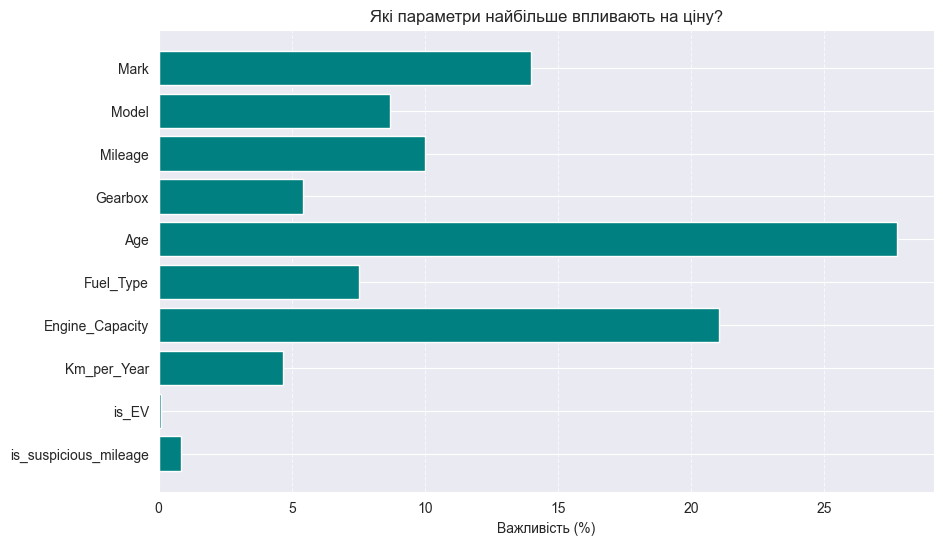

In [256]:
importance = model.get_feature_importance()
plt.figure(figsize=(10, 6))
plt.barh(features, importance, color='teal')
plt.xlabel('Важливість (%)')
plt.title('Які параметри найбільше впливають на ціну?')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

_______________________________
# Збереження моделі

In [257]:
ALLOWED_FUELS = [
    "Бензин", "Дизель", "Електро", "Газ",
    "Газ / Бензин", "Газ пропан-бутан / Бензин",
    "Гібрид (HEV)", "Гібрид (MHEV)", "Гібрид (PHEV)"
]

mark_model_mapping = {}
engine_mapping = {}
fuel_mapping = {}
gearbox_mapping = {}

# Проходимо по кожній марці
for mark in valid_marks:
    if mark == 'Other':
        continue

    mark_df = df_final[df_final['Mark'] == mark]

    # Фільтруємо моделі: залишаємо тільки ті, що є у valid_models
    models_for_mark = [m for m in mark_df['Model'].unique() if m in valid_models and m != 'Other']
    mark_model_mapping[mark] = sorted(models_for_mark)

    engine_mapping[mark] = {}
    fuel_mapping[mark] = {}
    gearbox_mapping[mark] = {}

    for model_name in models_for_mark:
        model_df = mark_df[mark_df['Model'] == model_name]

        # Очищення ТИПІВ ПАЛЬНОГО
        fuels = model_df['Fuel_Type'].unique()
        clean_fuels = [f for f in fuels if f in ALLOWED_FUELS]
        fuel_mapping[mark][model_name] = sorted(clean_fuels)

        # Очищення ОБ'ЄМІВ ДВИГУНІВ
        capacities = model_df[model_df['Engine_Capacity'] > 0]['Engine_Capacity'].unique()
        clean_capacities = sorted(list(set([round(float(c), 1) for c in capacities])))
        engine_mapping[mark][model_name] = clean_capacities

        # Рахуємо коробки передач
        gearbox_counts = model_df['Gearbox'].value_counts()
        valid_gearboxes = gearbox_counts[gearbox_counts >= 3].index.tolist()
        clean_gearboxes = sorted([g for g in valid_gearboxes if g not in ['Не вказано', 'Unknown', '', None]])

        if not clean_gearboxes:
            raw_gearboxes = [g for g in gearbox_counts.index.tolist() if g not in ['Не вказано', 'Unknown', '', None]]
            clean_gearboxes = [raw_gearboxes[0]] if raw_gearboxes else ["Автомат"]

        gearbox_mapping[mark][model_name] = clean_gearboxes

# Формуємо фінальний словник
valid_categories = {
    'valid_marks': [m for m in valid_marks if m != 'Other'],
    'valid_models': [m for m in valid_models if m != 'Other'],
    'mark_model_mapping': mark_model_mapping,
    'engine_mapping': engine_mapping,
    'fuel_mapping': fuel_mapping,
    'gearbox_mapping': gearbox_mapping
}

joblib.dump(valid_categories, '../src/backend/models/valid_categories.pkl')
model.save_model('../src/backend/models/catboost_car_price_model.cbm')